# 🎬 Movie Recommendation System  
## 📊 Data Exploration & Understanding (MovieLens 100K)

In this notebook, we explore the MovieLens dataset to understand user behavior, item popularity, and data sparsity before building the recommendation system.

This step is crucial because **recommendation systems are driven by interaction patterns**.


## 📥 Loading the Dataset

We load:
- **Ratings data** (user–movie interactions)
- **Movie metadata** (movie titles)

These will be used to analyze interaction patterns and later build the recommender.


In [7]:
import sys
from pathlib import Path

# Find project root dynamically (folder that contains "src")
current = Path().resolve()

for parent in [current] + list(current.parents):
    if (parent / "src").exists():
        PROJECT_ROOT = parent
        break

sys.path.append(str(PROJECT_ROOT))


In [11]:
import pandas as pd
import matplotlib.pyplot as plt

from src.data_loader import load_ratings, load_movies
ratings = load_ratings()
movies = load_movies()

ratings.head(), movies.head()

(   user_id  item_id  rating  timestamp
 0      196      242       3  881250949
 1      186      302       3  891717742
 2       22      377       1  878887116
 3      244       51       2  880606923
 4      166      346       1  886397596,
    item_id              title
 0        1   Toy Story (1995)
 1        2   GoldenEye (1995)
 2        3  Four Rooms (1995)
 3        4  Get Shorty (1995)
 4        5     Copycat (1995))

## 🔢 Basic Dataset Statistics

Let's understand the scale of the dataset.


In [12]:
print("Total interactions:", len(ratings))
print("Unique users:", ratings["user_id"].nunique())
print("Unique movies:", ratings["item_id"].nunique())
print("Rating range:", ratings["rating"].min(), "to", ratings["rating"].max())


Total interactions: 100000
Unique users: 943
Unique movies: 1682
Rating range: 1 to 5


## ⭐ Rating Distribution

Understanding how users rate movies helps us define what counts as a **relevant recommendation**.


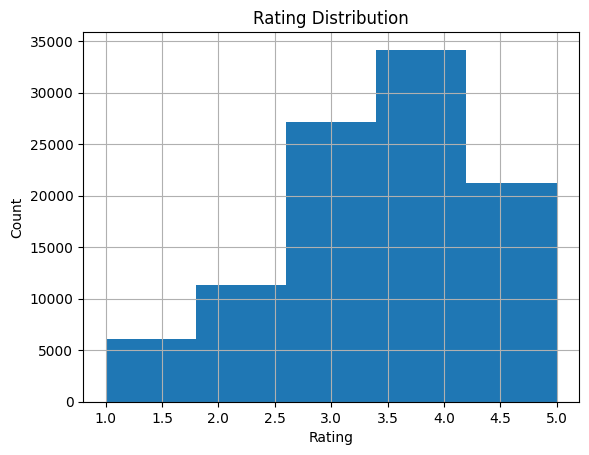

In [13]:
ratings["rating"].hist(bins=5)
plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()


## 👤 Interactions per User

Some users rate many movies, others very few.  
This affects how well collaborative filtering can personalize recommendations.


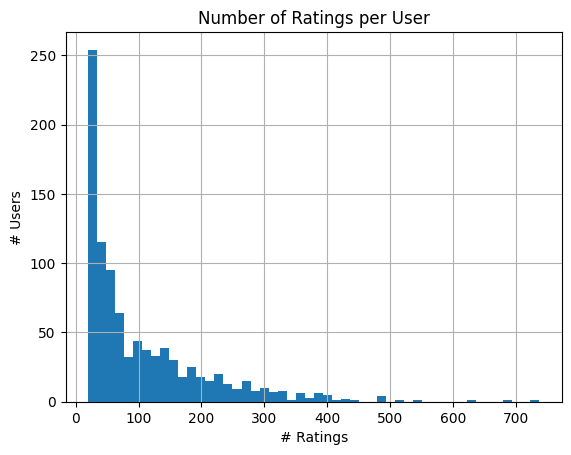

In [14]:
user_counts = ratings.groupby("user_id").size()
user_counts.hist(bins=50)
plt.title("Number of Ratings per User")
plt.xlabel("# Ratings")
plt.ylabel("# Users")
plt.show()


## 🎥 Interactions per Movie

This shows movie popularity distribution.  
A few movies receive many ratings, while most receive very few.


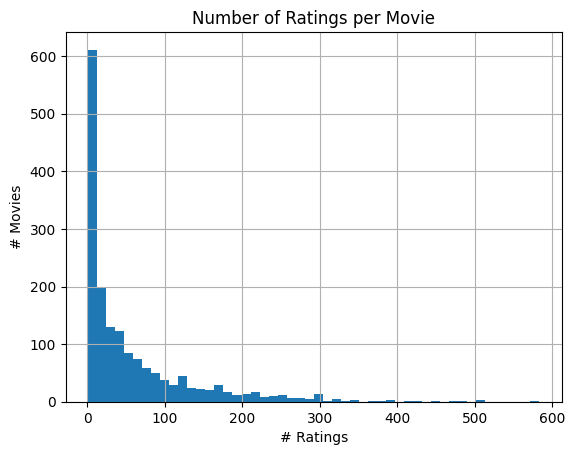

In [15]:
item_counts = ratings.groupby("item_id").size()
item_counts.hist(bins=50)
plt.title("Number of Ratings per Movie")
plt.xlabel("# Ratings")
plt.ylabel("# Movies")
plt.show()


## ✂️ Train / Test Split (Per User)

We split interactions per user to simulate real recommendation scenarios.  
This ensures each user has some history in training and future interactions in test.


In [16]:
from src.preprocessing import train_test_split_by_user, create_user_item_matrix

train_df, test_df = train_test_split_by_user(ratings, test_ratio=0.2)

print("Train size:", train_df.shape)
print("Test size:", test_df.shape)


Train size: (80367, 4)
Test size: (19633, 4)


## 🧩 User–Item Matrix Sparsity

Recommendation datasets are extremely sparse.  
This makes similarity-based approaches both powerful and challenging.


In [17]:
user_item_train = create_user_item_matrix(train_df)

nnz = (user_item_train.values != 0).sum()
total = user_item_train.shape[0] * user_item_train.shape[1]
sparsity = 1 - nnz / total

print("User–Item Matrix Shape:", user_item_train.shape)
print("Sparsity:", round(sparsity * 100, 2), "%")


User–Item Matrix Shape: (943, 1649)
Sparsity: 94.83 %


## 🤖 Example Recommendations

Let’s generate recommendations for one user using the trained model.


In [18]:
from src.model_itemcf import compute_item_similarity
from src.model_popularity import compute_popularity
from src.recommend import recommend_for_user

sim_matrix = compute_item_similarity(user_item_train)
pop_df = compute_popularity(train_df)
popularity_list = pop_df["item_id"].tolist()

user_id = 10

recs = recommend_for_user(
    user_id,
    user_item_train,
    sim_matrix,
    top_k=10,
    popularity_list=popularity_list,
    min_history=5
)

movies.set_index("item_id").loc[recs][["title"]]


,title
item_id,
204,Back to the Future (1985)
423,E.T. the Extra-Terrestrial (1982)
172,"Empire Strikes Back, The (1980)"
197,"Graduate, The (1967)"
89,Blade Runner (1982)
134,Citizen Kane (1941)
357,One Flew Over the Cuckoo's Nest (1975)
79,"Fugitive, The (1993)"
50,Star Wars (1977)


## 🧠 Insights from Exploration

- The dataset is **highly sparse**, typical for recommendation problems
- A few movies dominate in popularity, but personalization can uncover niche preferences
- Collaborative filtering is suitable because we have many overlapping user interactions

These observations motivate the use of **item-based collaborative filtering** with a fallback strategy.


## 🔍 Item Similarity (ItemCF)

Item-based Collaborative Filtering works by finding **movies that are similar** based on how users rated them.

Below we:
1) compute an item–item similarity matrix (cosine similarity)  
2) inspect the most similar movies for a chosen title  


In [19]:
from src.preprocessing import train_test_split_by_user, create_user_item_matrix
from src.model_itemcf import compute_item_similarity

# split
train_df, test_df = train_test_split_by_user(ratings, test_ratio=0.2)

# user-item matrix (train)
user_item_train = create_user_item_matrix(train_df)

# compute item similarity
sim_matrix = compute_item_similarity(user_item_train)

# helpers: mapping between item_id and column index
item_ids = user_item_train.columns.to_numpy()
item_id_to_idx = {item_id: idx for idx, item_id in enumerate(item_ids)}

print("Train matrix shape:", user_item_train.shape)
print("Similarity matrix shape:", sim_matrix.shape)


Train matrix shape: (943, 1649)
Similarity matrix shape: (1649, 1649)


### 🧩 Helper: Find Top-N Similar Movies

We’ll pick one movie and list the most similar ones based on ItemCF similarity.


In [20]:
import numpy as np

movies_by_id = movies.set_index("item_id")

def top_similar_movies(query_item_id, top_n=10):
    if query_item_id not in item_id_to_idx:
        return None
    
    idx = item_id_to_idx[query_item_id]
    sims = sim_matrix[idx].copy()

    # remove self
    sims[idx] = -np.inf

    top_idx = np.argsort(sims)[::-1][:top_n]
    top_item_ids = item_ids[top_idx]

    result = movies_by_id.loc[top_item_ids][["title"]].copy()
    result["similarity"] = sims[top_idx]
    return result

def find_item_id_by_title(title_substring):
    # naive search (good enough for demo)
    matches = movies[movies["title"].str.contains(title_substring, case=False, na=False)]
    return matches.head(10)


### 🎯 Example: Choose a Movie and Inspect Similar Titles

First, search for a movie by a substring, then pick an `item_id`.


In [21]:
find_item_id_by_title("Toy Story")


,item_id,title
0,1,Toy Story (1995)


In [22]:
# Example: Toy Story (1995) is usually item_id=1 in MovieLens 100K
top_similar_movies(query_item_id=1, top_n=10)


,title,similarity
item_id,,
50,Star Wars (1977),0.612824
181,Return of the Jedi (1983),0.563966
121,Independence Day (ID4) (1996),0.547072
174,Raiders of the Lost Ark (1981),0.520691
151,Willy Wonka and the Chocolate Factory (1971),0.516342
117,"Rock, The (1996)",0.514983
100,Fargo (1996),0.514941
237,Jerry Maguire (1996),0.513420
222,Star Trek: First Contact (1996),0.507911


### 📊 Similarity Scores (Top Similar Movies)

A quick visualization of similarity values for the top results.


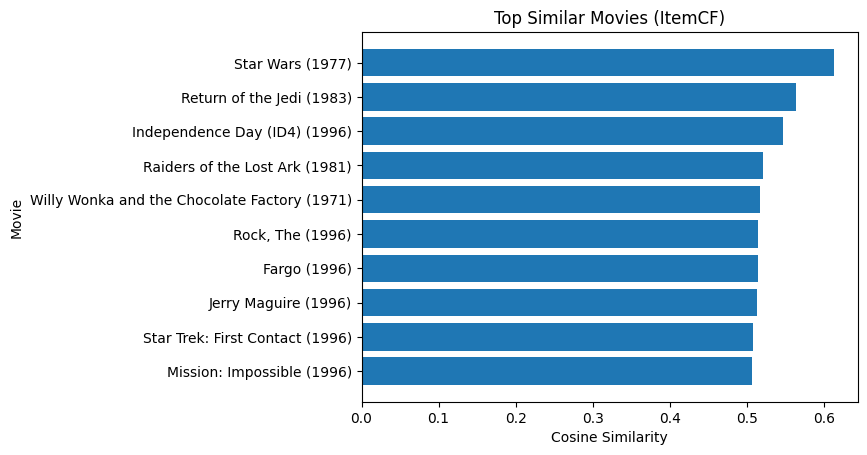

In [23]:
res = top_similar_movies(query_item_id=1, top_n=10)

plt.figure()
plt.barh(res["title"][::-1], res["similarity"][::-1])
plt.title("Top Similar Movies (ItemCF)")
plt.xlabel("Cosine Similarity")
plt.ylabel("Movie")
plt.show()
